In [23]:
import os
import re
import numpy as np            
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
sc.set_figure_params(dpi=100, color_map='viridis', fontsize=6)
sc.settings.verbosity=2
sc.settings.n_jobs=4
sc.logging.print_versions()

-----
anndata     0.10.9
scanpy      1.10.3
-----
PIL                         11.2.1
anyio                       NA
arrow                       1.3.0
asttokens                   NA
attr                        25.3.0
attrs                       25.3.0
babel                       2.17.0
backports                   NA
certifi                     2025.01.31
cffi                        1.17.1
charset_normalizer          3.4.1
comm                        0.2.2
cycler                      0.12.1
cython_runtime              NA
dateutil                    2.9.0.post0
debugpy                     1.8.14
decorator                   5.2.1
defusedxml                  0.7.1
exceptiongroup              1.2.2
executing                   2.2.0
fastjsonschema              NA
fqdn                        NA
h5py                        3.13.0
idna                        3.10
igraph                      0.11.8
importlib_resources         NA
ipykernel                   6.29.5
isoduration                 NA
ja

/home/liuxiaodongLab/jiangjing/.local/lib/python3.9/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)


In [129]:
adata = sc.read_h5ad("new_umap_dim18_spread2.5_mindist0.7_celltypes_250416.h5ad")

In [3]:
adata.obs['human_celltypes_250416']

rat12M_A_GGGCCATCAGGTAGTG-1                GABAL-2
rat12M_A_ACCCAAAGTAATGTGA-1                GABAL-1
rat12M_A_GCTGCAGCATCATCTT-1                 GLUL-2
rat12M_A_CCGGTAGCAAACATCC-1                GABAL-1
rat12M_A_GGTGATTCATCCGGTG-1                 GLUL-1
                                      ...         
P1B_AGAGCAGAGAGAGTTT-1                     GABAL-3
P1B_CACGAATAGTCATACC-1                        VLMC
P1B_AGAACAAAGACTGGGT-1         DA progenitor-FABP7
P1B_TAGGAGGGTAAGATTG-1                     GABAL-3
P1B_GCTCAAAAGAGTGAAG-1                     GABAL-3
Name: human_celltypes_250416, Length: 47711, dtype: category
Categories (24, object): ['Glial progenitors', 'Astrocyte progenitor cells', 'Astrocyte', 'VLMC', ..., 'DA progenitor-CHRNA6 low', 'DA progenitor-terminal', 'Immature DA', 'Mature DA']

In [548]:
# 定义要分析的多个细胞类型
target_types = ['Rgl1-like', 'DA progenitor-FABP7', 'DA progenitor-CHRNA6 high','DA progenitor-CHRNA6 low','DA progenitor-terminal',
               'Immature DA','Mature DA']  # 替换为你的目标类型

# 提取多类别子集（保留交集基因）
adata_sub = adata[adata.obs['human_celltypes_250416'].isin(target_types), :].copy()

# 检查细胞数量分布
print(adata_sub.obs['human_celltypes_250416'].value_counts())

human_celltypes_250416
DA progenitor-FABP7          4886
DA progenitor-terminal       2011
Rgl1-like                    1425
DA progenitor-CHRNA6 low      957
DA progenitor-CHRNA6 high     865
Immature DA                   756
Mature DA                     132
Name: count, dtype: int64


computing neighbors
    finished (0:00:02)
computing UMAP
    finished (0:00:09)


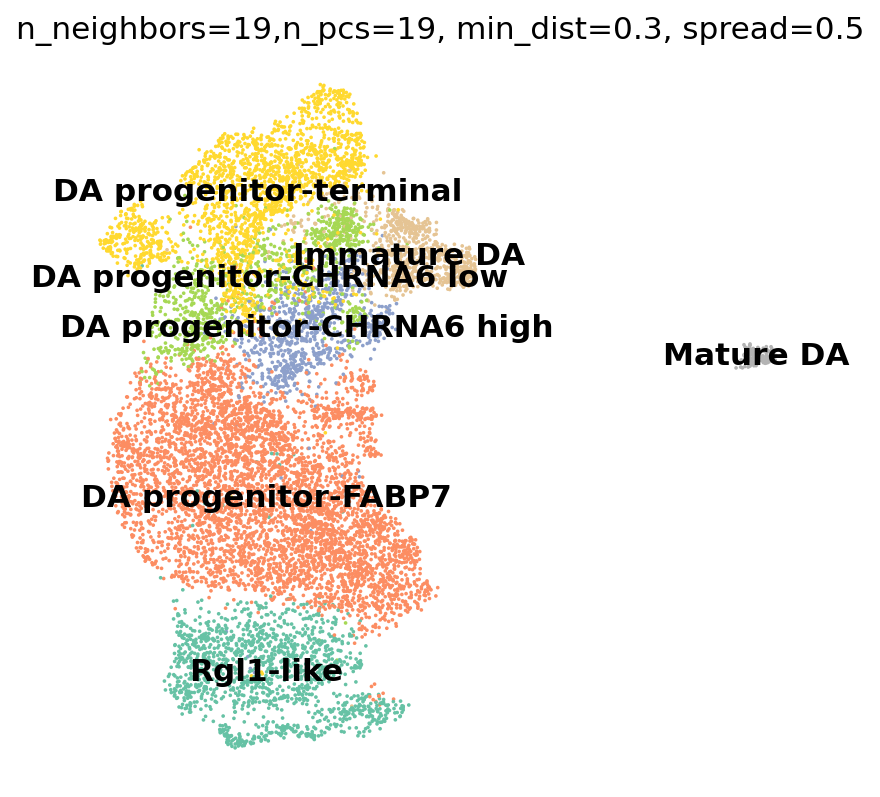

In [466]:
n_neighbors=19
n_pcs=19
min_dist=0.3
spread=0.5

sc.pp.neighbors(
    adata_sub, 
    n_neighbors=n_neighbors, 
    n_pcs=n_pcs,  # 使用校正后的前30个PC
    use_rep='X_integrated.rpca' # 明确指定使用校正后的PCA
)
sc.tl.umap(adata_sub, min_dist=min_dist,spread=spread)
sc.pl.umap(
       adata_sub,
       color='human_celltypes_250416',
       palette='Set2',
       legend_loc='on data',
       frameon=False,
       title=f'n_neighbors={n_neighbors},n_pcs={n_pcs}, min_dist={min_dist}, spread={spread}',
       save=f'UMAP_n_neighbors{n_neighbors}_npcs{n_pcs}_mindist{min_dist}_spread{spread}.png'
   )

computing tSNE
    using sklearn.manifold.TSNE
    finished (0:00:34)


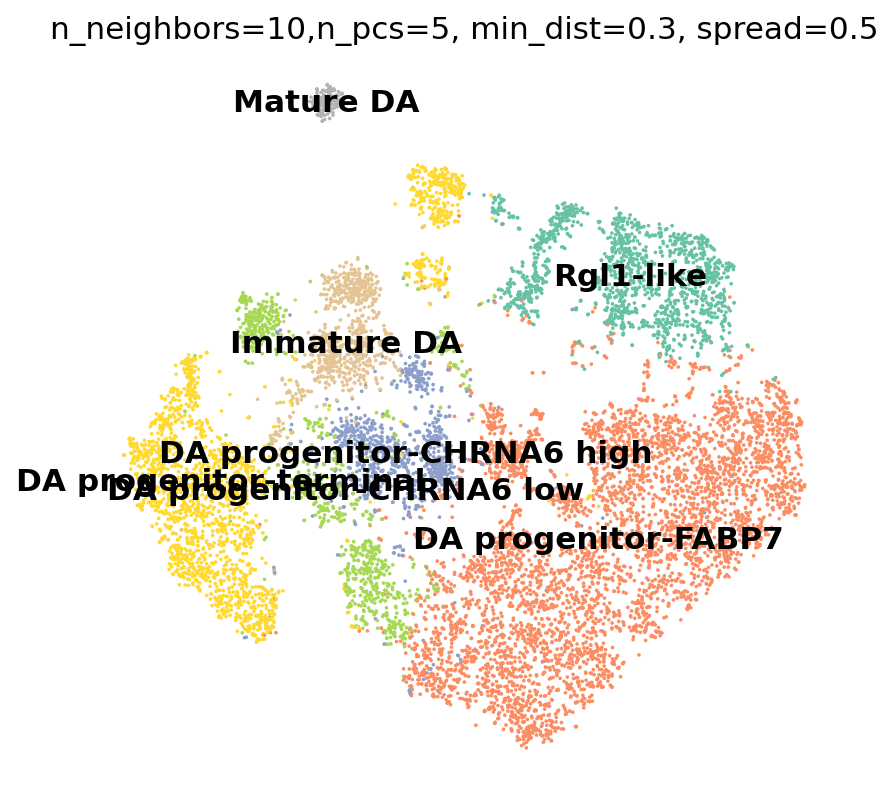

In [563]:

sc.tl.tsne(adata_sub,n_pcs=20,perplexity=50,use_rep='X_integrated.rpca')
sc.pl.tsne(
       adata_sub,
       color='human_celltypes_250416',
       palette='Set2',
       legend_loc='on data',
       frameon=False,
       title=f'n_neighbors={n_neighbors},n_pcs={n_pcs}'
       #save=f'UMAP_n_neighbors{n_neighbors}_npcs{n_pcs}.png'
   )

running PAGA
    finished (0:00:00)


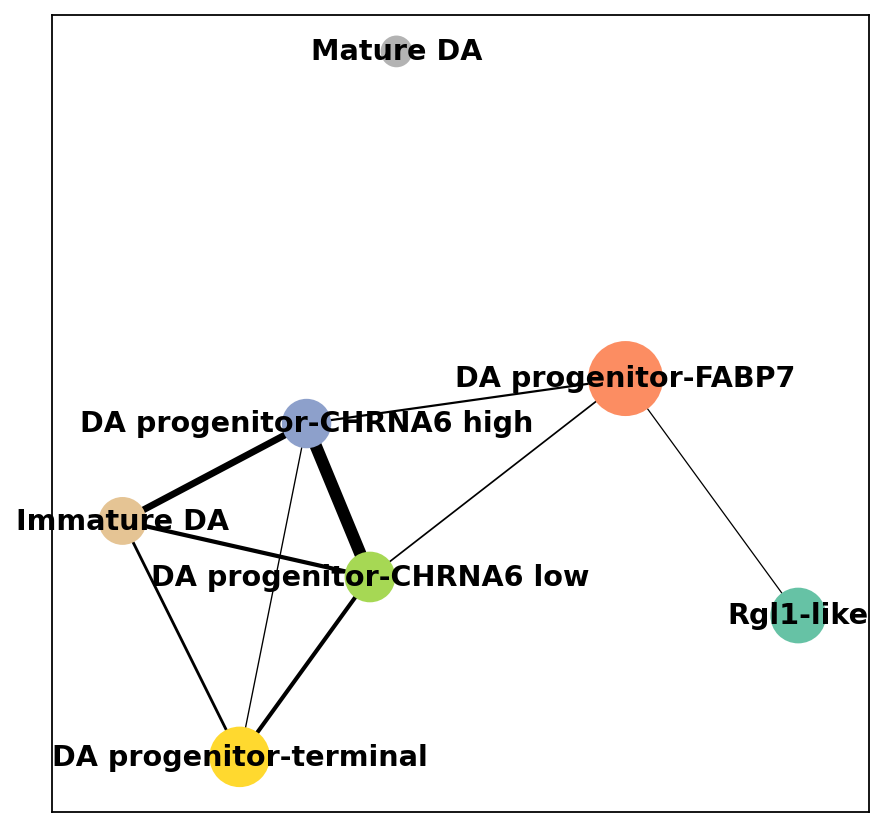

computing UMAP
    finished (0:00:08)


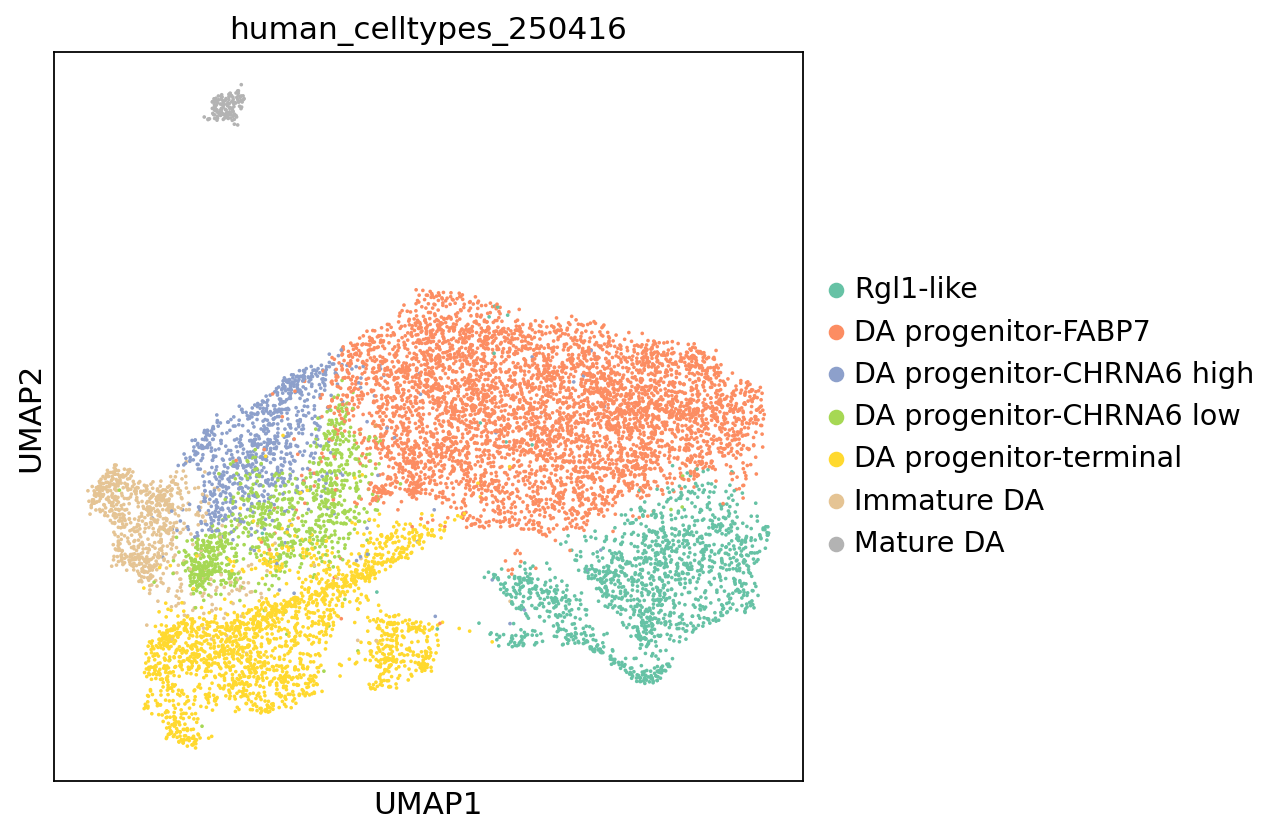

In [470]:
# 2. 运行PAGA轨迹分析
sc.tl.paga(adata_sub, groups='human_celltypes_250416')

# 3. 可视化PAGA轨迹
sc.pl.paga(
    adata_sub,
    color='human_celltypes_250416',
    threshold=0.05,  # 调整连接阈值
    node_size_scale=3
)

# 4. 将PAGA结构投影到UMAP
#sc.tl.umap(adata_sub, init_pos='paga', min_dist=min_dist, spread=spread)
#sc.pl.umap(adata_sub, color='human_celltypes_250416', palette='Set2')

In [408]:
sc.set_figure_params(figsize=(6,6), frameon=True)  # frameon=True 显示坐标系背景
n_neighbors=11
n_pcs=21
min_dist=0.1
spread=0.5

sc.pp.neighbors(
    adata_sub, 
    n_neighbors=n_neighbors, 
    n_pcs=n_pcs,  # 使用校正后的前30个PC
    use_rep='X_integrated.rpca' # 明确指定使用校正后的PCA
)
sc.tl.umap(adata_sub, min_dist=min_dist,spread=spread)
sc.pl.umap(
       adata_sub,
       color='human_celltypes_250416',
       palette='Set2',
       legend_loc='on data',
       show=False,
       title=f'n_neighbors={n_neighbors},n_pcs={n_pcs}, min_dist={min_dist}, spread={spread}'
       # save=f'UMAP_n_neighbors{n_neighbors}_npcs{n_pcs}_mindist{min_dist}_spread{spread}.png'
   )
plt.savefig(f'./test_figures/UMAP_n_neighbors{n_neighbors}_npcs{n_pcs}_mindist{min_dist}_spread{spread}.png', dpi=300, bbox_inches='tight')
plt.close()

computing neighbors
    finished (0:00:02)
computing UMAP
    finished (0:00:07)


In [ ]:
for res in np.round(np.arange(0.1, 3.0, 0.5),1):
    sc.tl.leiden(adata_sub, resolution=res, key_added=f'leiden_{res}')
    sc.pl.umap(adata_sub, color='human_celltypes_250416', title=f'Resolution={res}')

In [ ]:
import itertools  # 用于生成参数组合

# 定义待测试的参数范围
n_pcs_list = list(range(10, 30))        # 测试不同的 n_pcs 值
min_dist_list = np.round(np.arange(0.1, 0.7, 0.2),1)  # UMAP 的 min_dist 参数
spread_list = np.round(np.arange(0.5, 3, 0.5),1)   # UMAP 的 spread 参数

# 遍历所有参数组合
for n_pcs, min_dist, spread in itertools.product(n_pcs_list, min_dist_list, spread_list):
    # 复制原始数据，避免覆盖原有结果
    adata_temp = adata_sub.copy()
    
    # Step 1: 计算邻居图（使用当前 n_pcs）
    sc.pp.neighbors(
        adata_temp,
        n_neighbors=10,
        n_pcs=n_pcs,
        use_rep='X_integrated.rpca'  # 确保使用已校正的 PCA
    )
    
    # Step 2: 计算 UMAP（应用当前 min_dist 和 spread）
    sc.tl.umap(
        adata_temp,
        min_dist=min_dist,
        spread=spread
    )
    
    # Step 3: 绘制 UMAP 图并标注参数
    sc.pl.umap(
        adata_temp,
        color='human_celltypes_250416',
        palette='Set2',
        title=f'n_pcs={n_pcs}, min_dist={min_dist}, spread={spread}',  # 标题显示参数
        legend_loc='on data',
        legend_fontsize=10,
        legend_fontoutline=2,
        frameon=False,
        show=False  # 避免自动显示，便于批量保存
    )
    
    # 可选：保存图片到文件
    plt.savefig(f'./test_figures/UMAP_npcs{n_pcs}_mindist{min_dist}_spread{spread}.png', dpi=300, bbox_inches='tight')
    plt.close()  # 关闭当前图像，释放内存

In [84]:
adata_sub.X

<11032x24190 sparse matrix of type '<class 'numpy.float64'>'
	with 44761820 stored elements in Compressed Sparse Column format>

In [85]:
adata.write("monocle3_use_scanpy_umap.h5ad")

In [63]:
# 设置绘图参数（显示坐标轴）
sc.set_figure_params(figsize=(12,12), dpi=150, frameon=True)  # frameon=True 显示坐标系背景

# 1. 绘制基础UMAP图
ax = sc.pl.umap(
    adata_sub,
    color='human_celltypes_250416',
    palette='Set2',
    legend_loc="on data",          # 禁用默认图例
    title='',
    show=False                # 不自动显示
)

# 2. 添加坐标轴标签
ax.set_xlabel("UMAP1", fontsize=12, labelpad=10)
ax.set_ylabel("UMAP2", fontsize=12, labelpad=10)

# 3. 显式显示坐标轴线和刻度
ax.spines['left'].set_visible(True)   # 显示左侧Y轴
ax.spines['bottom'].set_visible(True) # 显示底部X轴
ax.tick_params(axis='both', which='both', 
               length=4, width=1,     # 调整刻度线长度和粗细
               labelsize=10)

# 4. 创建并定位自定义图例
categories = adata_sub.obs['human_celltypes_250416'].cat.categories
colors = adata_sub.uns['human_celltypes_250416_colors']

legend_elements = [plt.Line2D(
    [0], [0],
    marker='o',
    color='w',
    markersize=8,
    markerfacecolor=colors[i],
    label=cat
) for i, cat in enumerate(categories)]

# 将图例定位在右侧中间
leg = plt.legend(
    handles=legend_elements,
    title='',
    bbox_to_anchor=(1.15, 0.5),  # 右侧中间位置 (x,y)
    loc='center left',           # 定位点对齐方式
    borderaxespad=0.3,           # 图例与画布的间距
    frameon=False,               # 无边框
    title_fontsize=12,
    fontsize=10,
    handletextpad=0.5           # 图标与文字间距
)

# 5. 保存高清图像
plt.savefig(
    'labeled_umap.png',
    dpi=300,
    bbox_extra_artists=(leg,),   # 包含手动添加的图例
    bbox_inches='tight',         # 自动调整边界
    pad_inches=0.5               # 边距扩展
)
plt.close()

In [575]:
sc.pp.neighbors(
    adata_sub, 
    n_neighbors=10, 
    n_pcs=9,  # 使用校正后的前30个PC
    use_rep='X_integrated.rpca' # 明确指定使用校正后的PCA
)


computing neighbors
    finished (0:00:02)


In [576]:
# 计算Diffusion Map和DPT伪时间
sc.tl.diffmap(adata_sub,n_comps=10)
root_cell = adata_sub.obs['human_celltypes_250416'] == 'Rgl1-like'  # 设置根细胞类型
adata_sub.uns['iroot'] = np.where(root_cell)[0][0]  # 取第一个TypeA细胞作为根
sc.tl.dpt(adata_sub)

computing Diffusion Maps using n_comps=10(=n_dcs)
computing transitions
    finished (0:00:00)
    eigenvalues of transition matrix
    [1.         0.99643993 0.99214363 0.99149066 0.98669577 0.98341966
     0.9810538  0.97895867 0.97857046 0.97331256]
    finished (0:00:00)
computing Diffusion Pseudotime using n_dcs=10
    finished (0:00:00)


AttributeError: PathCollection.set() got an unexpected keyword argument 'flip_y'

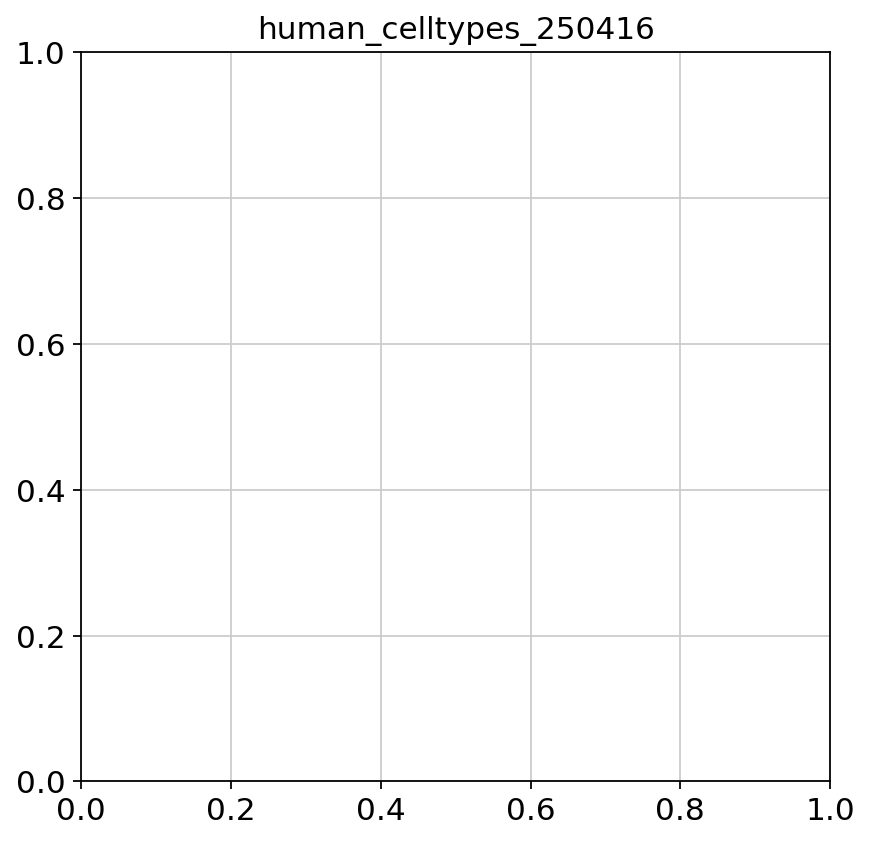

In [582]:
sc.pl.diffmap(
    adata_sub,
    color=['human_celltypes_250416'],
    components=('2,4'),  # 选关键扩散成分
    size=20,
    palette='tab20',  # 保证多类别颜色区分
    save='_multi_celltype_diffmap_1.png'
)

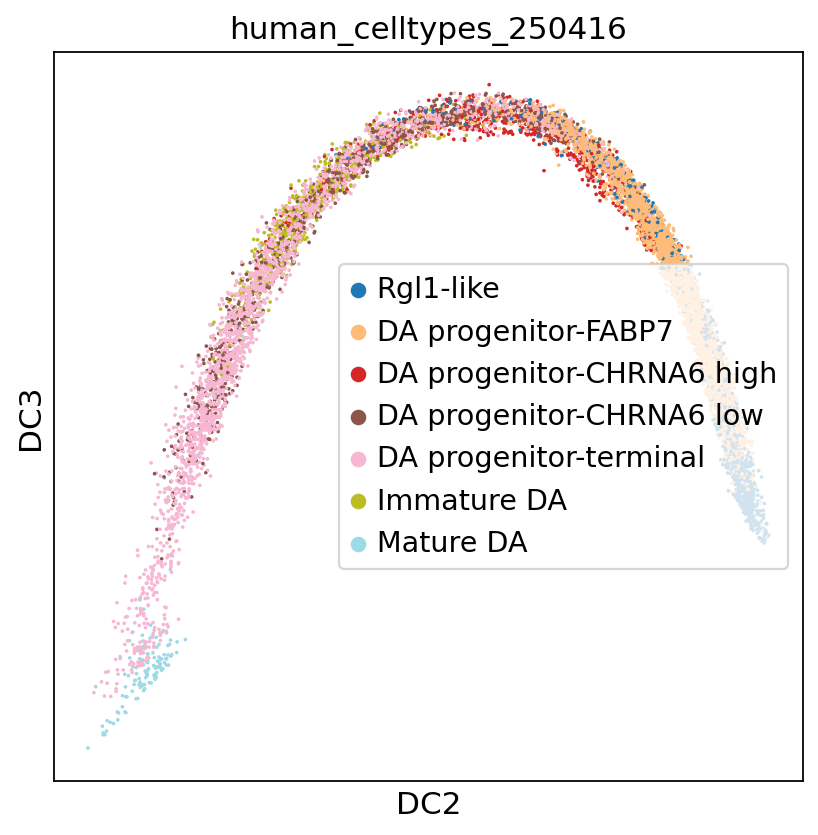

In [556]:
sc.pl.diffmap(
    adata_sub,
    color=['human_celltypes_250416'],
    components=('2,3'),  # 选关键扩散成分
    legend_loc='right',
    palette='tab20',  # 保证多类别颜色区分
    save='_multi_celltype_diffmap_1.png'
)

In [549]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

# --------------------------
# 配置参数
# --------------------------
config = {
    # 批次参数
    'batch_key': 'batch',  
    
    # 根细胞定义
    'root_celltype': 'Rgl1-like',
    
    'n_neighbors': range(10, 21,2),  # 邻域数范围
    'n_pcs': range(5, 21,2),    # 主成分范围
    'n_comps' : range(10, 21,5) ,     # 扩散成分数范围
    
    # 成分组合参数
    'fixed_component': 2,  # 固定成分的索引（0-based）
    'variable_components': range(0, 10)  # 动态成分索引(对应显示值1-10)
}

# --------------------------
# 预检查
# --------------------------
# 确认根细胞存在
if config['root_celltype'] not in adata_sub.obs['human_celltypes_250416'].cat.categories:
    raise ValueError(f"根细胞类型 {config['root_celltype']} 不存在于数据中！")

# 创建输出目录
Path("./diffmap_results").mkdir(exist_ok=True)

# --------------------------
# 主分析循环
# --------------------------
for nn in config['n_neighbors']:
    for pcs in config['n_pcs']:
        for comps in config['n_comps']:
            # 跳过无效的PCA维度
            if pcs > adata_sub.obsm['X_integrated.rpca'].shape[1]:
                print(f"跳过 n_pcs={pcs}（超过可用维度）")
                continue
                
            # 生成唯一参数ID
            param_id = f"nn{nn}_pcs{pcs}_comp{comps}"
            print(f"\n=== 正在处理参数组合: {param_id} ===")
            
            # 1. 计算邻域图
            try:
                sc.pp.neighbors(
                    adata_sub,
                    n_neighbors=nn,
                    n_pcs=pcs,
                    use_rep='X_integrated.rpca'
                )
            except Exception as e:
                print(f"邻域图计算失败: {str(e)}")
                continue
                
            # 2. 扩散映射计算
            try:
                sc.tl.diffmap(
                    adata_sub,
                    n_comps=comps,
                    random_state=42
                )
            except Exception as e:
                print(f"扩散映射计算失败: {str(e)}")
                continue
                
            # 3. 伪时间分析
            try:
                root_mask = adata_sub.obs['human_celltypes_250416'] == config['root_celltype']
                adata_sub.uns['iroot'] = np.where(root_mask)[0][0]
                sc.tl.dpt(adata_sub) #, n_branchings=1, min_group_size=1
            except Exception as e:
                print(f"伪时间计算失败: {str(e)}")
                continue
                
            # 4. 动态成分可视化
            for var_idx in config['variable_components']:
                # 检查成分有效性
                if var_idx >= comps:
                    print(f"跳过成分 {var_idx}（超过计算的n_comps={comps}）")
                    continue
                    
                # 修复components参数类型（使用字符串格式）
                fixed_show = config['fixed_component']
                var_show = var_idx + 1
                components_str = f"{fixed_show},{var_show}"
                
                # 可视化（修复后的参数传递）
                fig, axs = plt.subplots(1, 2, figsize=(24, 10))
                plt.suptitle(f"Parameters: {param_id}\nComponents: {components_str}", fontsize=16)
                
                # 子图1：使用字符串指定components
                sc.pl.diffmap(
                    adata_sub,
                    color='human_celltypes_250416',
                    components=components_str,
                    ax=axs[0],
                    show=False,
                    legend_loc='on data',
                    palette='tab20'
                )
                
                # 子图2：伪时间轨迹
                sc.pl.diffmap(
                    adata_sub,
                    color='dpt_pseudotime',
                    components=components_str,
                    ax=axs[1],
                    show=False,
                    color_map='viridis'
                )
                
                filename = f"./diffmap_results/{param_id}_comp{components_str.replace(',','_')}.png"
                plt.savefig(filename, bbox_inches='tight', dpi=150)
                plt.close()
                
            # 释放内存（可选）
            del adata_sub.obsm['X_diffmap'], adata_sub.obs['dpt_pseudotime']
            if 'dpt_groups' in adata_sub.obs:
                del adata_sub.obs['dpt_groups']


print("所有分析完成！结果保存在 ./diffmap_results 目录")



=== 正在处理参数组合: nn10_pcs5_comp10 ===
computing neighbors
    finished (0:00:02)
computing Diffusion Maps using n_comps=10(=n_dcs)
computing transitions
    finished (0:00:00)
    eigenvalues of transition matrix
    [1.         0.9988382  0.9951264  0.99239343 0.98882526 0.98657215
     0.98393023 0.9826774  0.9812775  0.9761298 ]
    finished (0:00:00)
computing Diffusion Pseudotime using n_dcs=10
    finished (0:00:00)

=== 正在处理参数组合: nn10_pcs5_comp15 ===
computing neighbors
    finished (0:00:02)
computing Diffusion Maps using n_comps=15(=n_dcs)
computing transitions
    finished (0:00:00)
    eigenvalues of transition matrix
    [1.         0.9988382  0.9951264  0.99239343 0.98882526 0.98657215
     0.98393023 0.9826774  0.9812775  0.9761298  0.9747741  0.9704556
     0.9696273  0.9680225  0.9649805 ]
    finished (0:00:00)
computing Diffusion Pseudotime using n_dcs=10
    finished (0:00:00)

=== 正在处理参数组合: nn10_pcs5_comp20 ===
computing neighbors
    finished (0:00:02)
computing Diff

In [ ]:
# ----------- 可视化扩散映射 -----------
# 方式1：绘制默认的前两个扩散分量（分量1 vs 分量2）
sc.pl.embedding(
    adata_sub, 
    basis='diffmap',  # 使用原始扩散坐标
    color=['human_celltypes_250416'],  # 根据细胞类型着色
    components=['2,3'],   # 选择分量1和2
    title='Diffusion Map (Components 1 vs 2)'
)

In [ ]:
sc.tl.umap(adata_sub)
sc.pl.umap(
    adata_sub,
    color=['human_celltypes_250416', 'dpt_pseudotime'],
    frameon=False,
    title=['human_celltypes_250416', 'Pseudotime'],
    palette='viridis',
    ncols=2,
    save='_multi_celltype_umap_1.png'
)

In [ ]:
# 检查分支信息
print(adata_sub.obs['dpt_groups'].value_counts())

# 绘制分支轨迹
sc.pl.diffmap(
    adata_sub,
    color='dpt_groups',
    components='1,2',
    legend_loc='right margin',
    save='_trajectory_branches.png'
)

In [272]:
sc.pp.neighbors(
    adata_sub, 
    n_neighbors=10, 
    n_pcs=5,  # 使用校正后的前30个PC
    use_rep='X_integrated.rpca'  # 明确指定使用校正后的PCA
)


computing neighbors
    finished (0:00:02)


running PAGA
    finished (0:00:00)


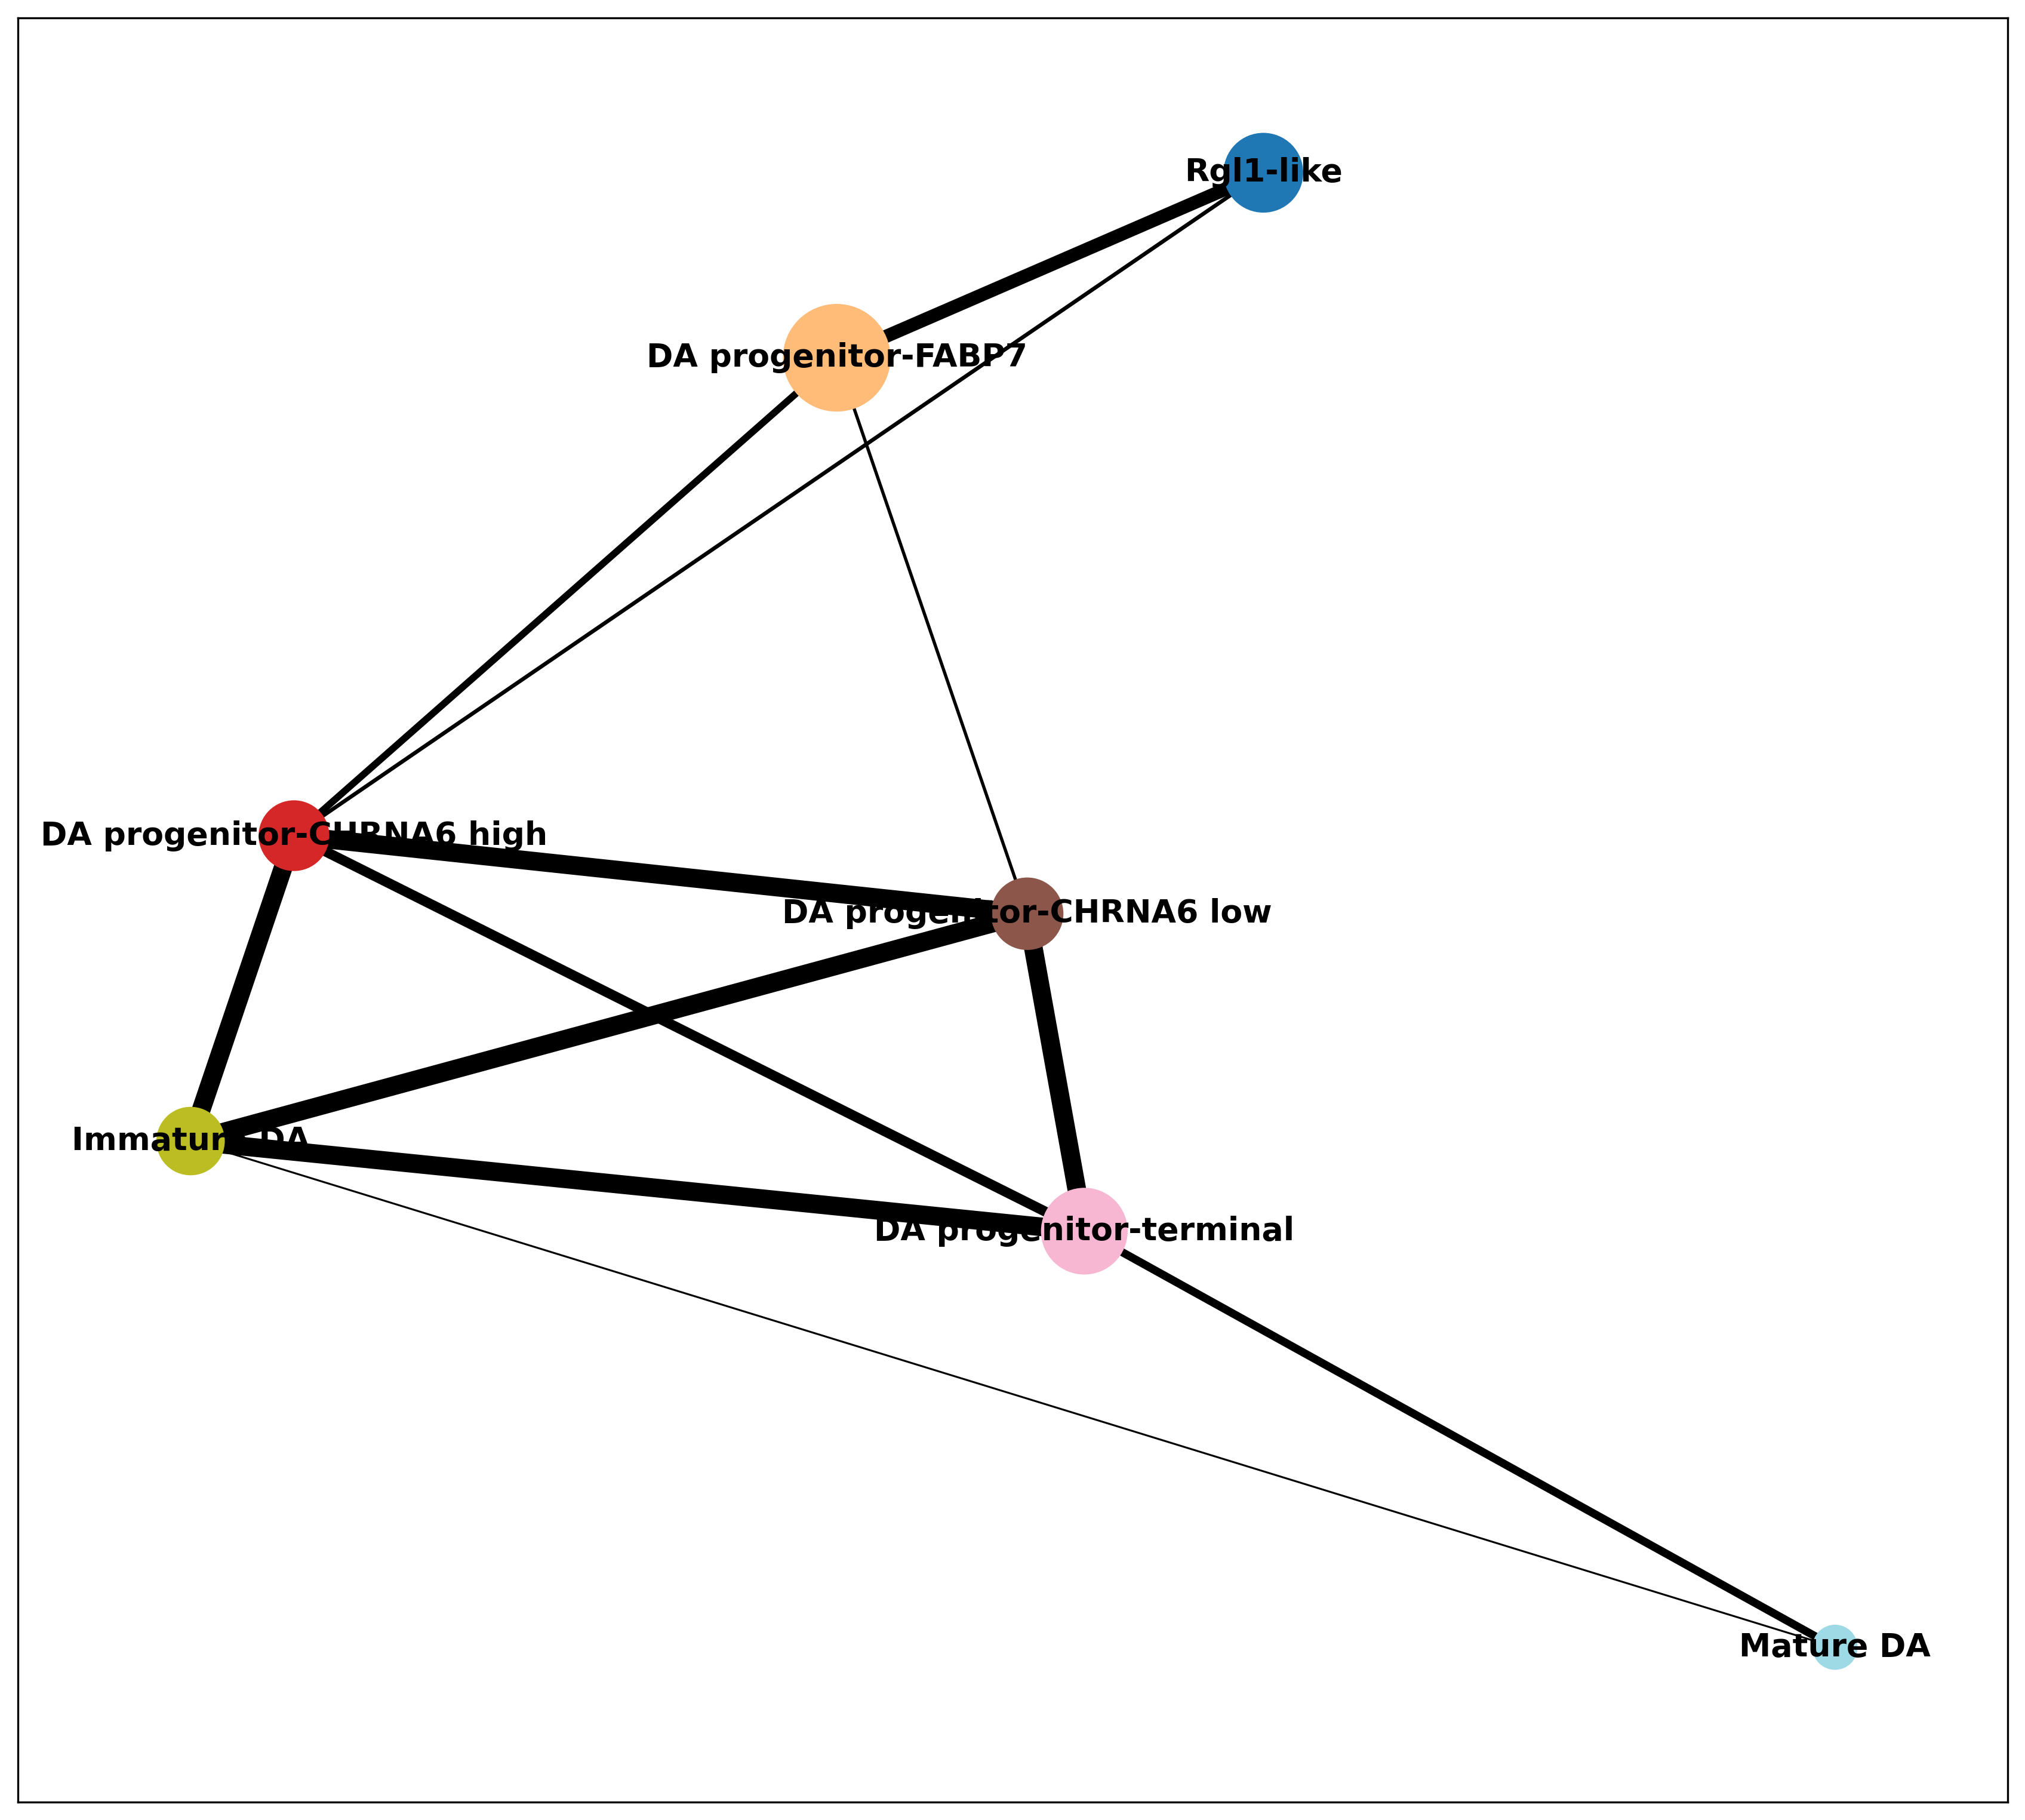

In [274]:
# 使用PAGA分析轨迹拓扑
sc.tl.paga(adata_sub, groups='human_celltypes_250416')
sc.pl.paga(
    adata_sub,
    color='human_celltypes_250416',
    layout='fa',  # force-directed layout
    threshold=0.1,
    node_size_scale=5,
    save='_paga_trajectory.png'
)

In [168]:
adata_sub.obs

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,RNA_snn_res.0.1,RNA_snn_res.0.2,RNA_snn_res.0.3,RNA_snn_res.0.4,RNA_snn_res.0.5,RNA_snn_res.0.6,...,RNA_snn_res.2.9,RNA_snn_res.3,human_celltypes_250325,human_celltypes_250327,human_celltypes_250330,human_celltypes_250416,dpt_pseudotime,dpt_groups,dpt_order,dpt_order_indices
rat12M_A_CTCCTCCAGCTGCCTG-1,rat12M_A,10659.0,4900.0,0.189873,1,3,13,5,21,20,...,31,30,DAN-1,DAN-1,DAN-1,Immature DA,0.410521,3,11027,47
rat12M_A_CAGGCCACATTGTTGG-1,rat12M_A,22573.0,6803.0,0.495028,1,3,13,5,11,12,...,29,28,DAP-3,DAP-3-wanted,DAP-3-wanted,DA progenitor-CHRNA6 high,0.309769,0,935,237
rat12M_A_CTGTCGTGTGAGCGAT-1,rat12M_A,20958.0,6921.0,0.036770,1,3,13,5,11,12,...,29,28,DAP-3,DAP-3-wanted,DAP-3-wanted,DA progenitor-CHRNA6 high,0.305678,2,10323,2012
rat12M_A_GTTACCCGTTGATGTC-1,rat12M_A,20339.0,6916.0,0.177396,1,3,13,5,21,20,...,61,63,DAN-1,DAP-3-wanted,DAP-3-wanted,DA progenitor-CHRNA6 high,0.304919,0,435,773
rat12M_A_CGGGACTGTCAGGAGT-1,rat12M_A,20612.0,6628.0,0.056649,1,3,13,5,21,20,...,31,30,DAN-1,DAN-1,DAN-1,Immature DA,0.401874,3,10956,46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P1B_CAGCGTGCACTGCATA-1,SeuratProject,6576.0,3003.0,3.443158,1,3,12,13,13,11,...,3,4,DAP-4,DAP-4,DAP-4,DA progenitor-terminal,0.313668,0,7884,0
P1B_GAAATGAGTTGTCATG-1,SeuratProject,11968.0,4997.0,3.083306,1,0,10,11,14,15,...,17,14,DAP-1,DAP-1,DAP-1,Rgl1-like,0.311643,0,6432,10
P1B_ATCAGGTCATTGCAGT-1,SeuratProject,7269.0,3317.0,3.226238,1,0,0,0,0,0,...,1,3,DAP-2,DAP-2,DAP-2,DA progenitor-FABP7,0.311270,0,5104,1640
P1B_CTCATTAAGCATTTAC-1,SeuratProject,3150.0,1852.0,7.960644,1,0,0,0,0,0,...,1,3,DAP-2,DAP-2,DAP-2,DA progenitor-FABP7,0.310693,0,2576,770


In [ ]:
n_neighbors_list = list(range(10, 50,5))  # 50,55,...,100 (包含100)
n_pcs_list = list(range(15, 25))            # 15,16,...,25
threshold_list = np.round(np.arange(0.05, 0.10, 0.01),2)  

# ====================
# 安全参数检查
# ====================
max_available_pcs = adata_sub.obsm['X_pca'].shape[1]
n_pcs_list = [p for p in n_pcs_list if p <= max_available_pcs]

# ====================
# 循环生成所有组合
# ====================
for n_neighbors in n_neighbors_list:
    for n_pcs in n_pcs_list:
        # 动态计算neighbors
        sc.pp.neighbors(
            adata_sub,
            n_neighbors=n_neighbors,
            n_pcs=n_pcs,
            use_rep='X_pca'
        )
        
        # 必须重新运行PAGA
        sc.tl.paga(adata_sub, groups='human_celltypes_250416')
        
        for threshold in threshold_list:
            # 生成唯一文件名
            fname = f"paga_nn{n_neighbors:03d}_pcs{n_pcs:02d}_th{threshold:.2f}"
            
            # 绘图配置
            with plt.rc_context({'figure.figsize': (10,8), 'figure.dpi': 150}):
                ax = sc.pl.paga(
                    adata_sub,
                    color='human_celltypes_250416',
                    layout='fa',
                    threshold=threshold,
                    node_size_scale=5,
                    title=(
                        f'n_neighbors={n_neighbors}\n'  # 参数标题
                        f'n_pcs={n_pcs}\n'
                        f'threshold={threshold}'
                    ),
                    frameon=False,
                    show=False
                )
                
                # 保存高清图片
                plt.savefig(
                    f"{fname}.png",
                    bbox_inches='tight',
                    pad_inches=0.3,
                    transparent=True  # 背景透明便于后期排版
                )
                plt.close()  # 防止内存泄漏

print(f"已完成 {len(n_neighbors_list)}x{len(n_pcs_list)}x{len(threshold_list)} 组合的可视化！")


In [14]:
# 创建不删除第一分量的视图（保留原始扩散分量）
adata.obsm['X_diffmap_raw'] = adata.obsm['X_diffmap']  # 备份原始扩散坐标

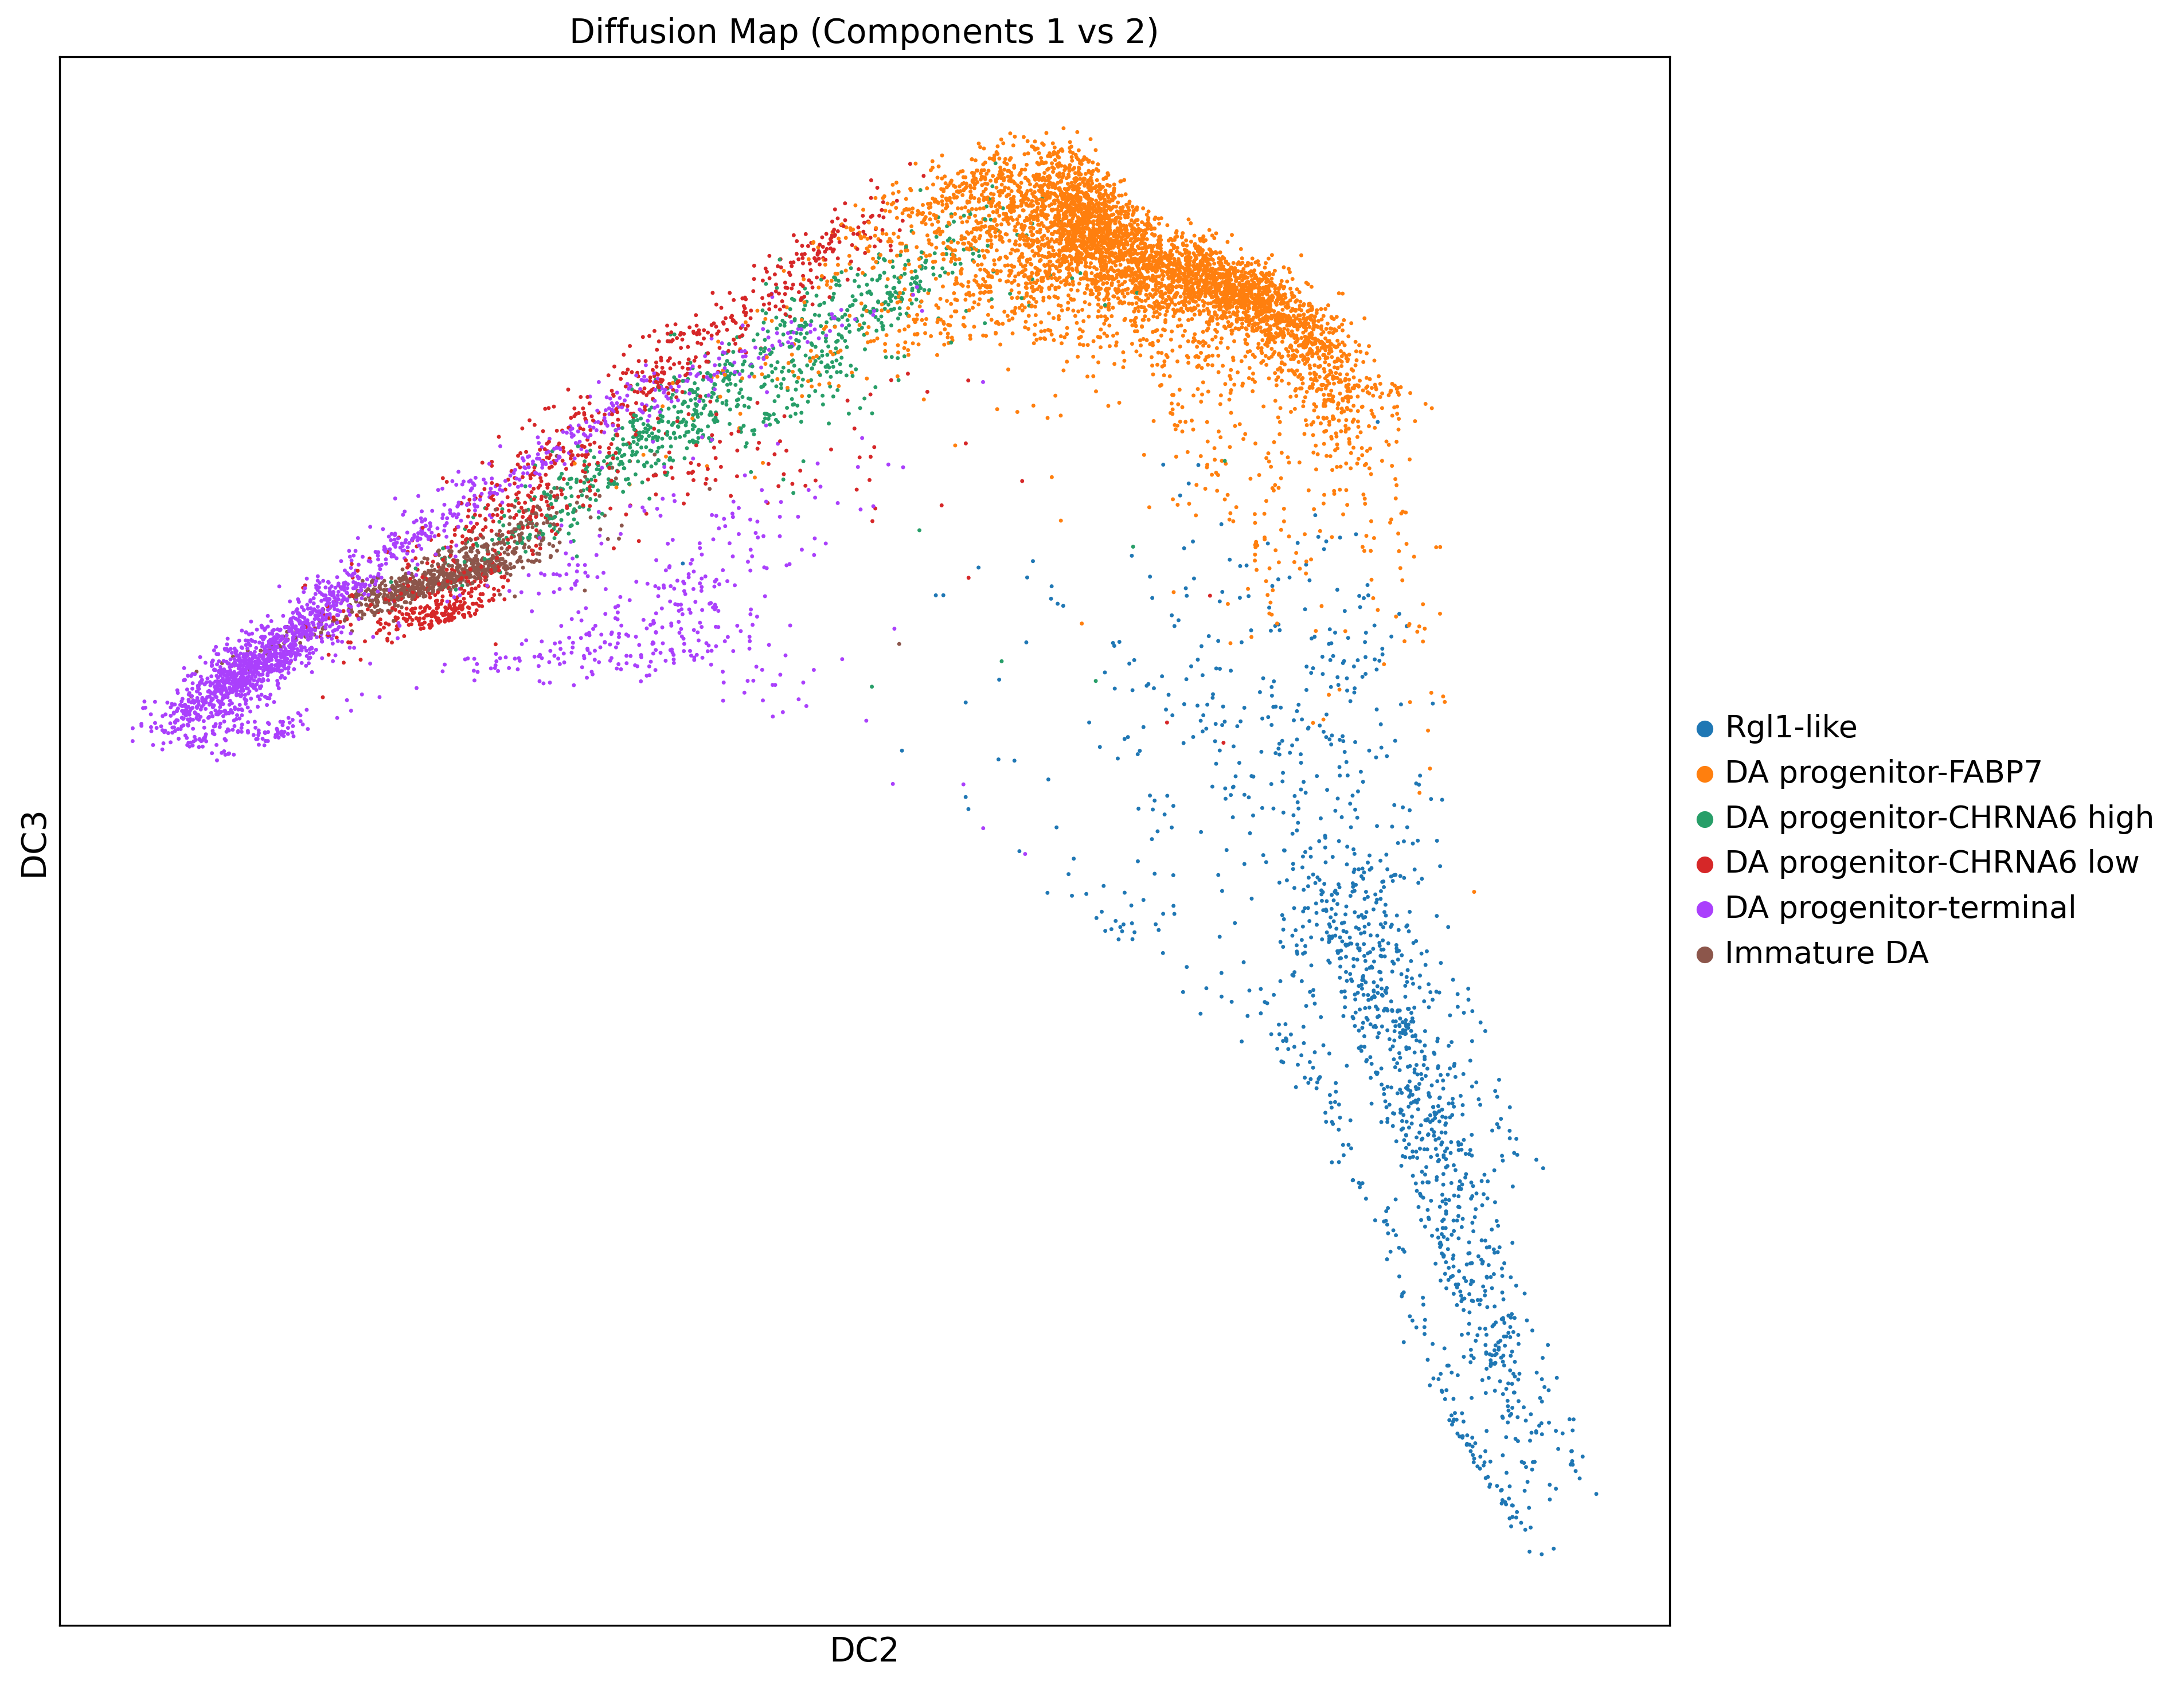

In [147]:
# ----------- 可视化扩散映射 -----------
# 方式1：绘制默认的前两个扩散分量（分量1 vs 分量2）
sc.pl.embedding(
    adata_sub, 
    basis='diffmap',  # 使用原始扩散坐标
    color=['human_celltypes_250416'],  # 根据细胞类型着色
    components=['2,3'],   # 选择分量1和2
    title='Diffusion Map (Components 1 vs 2)'
)

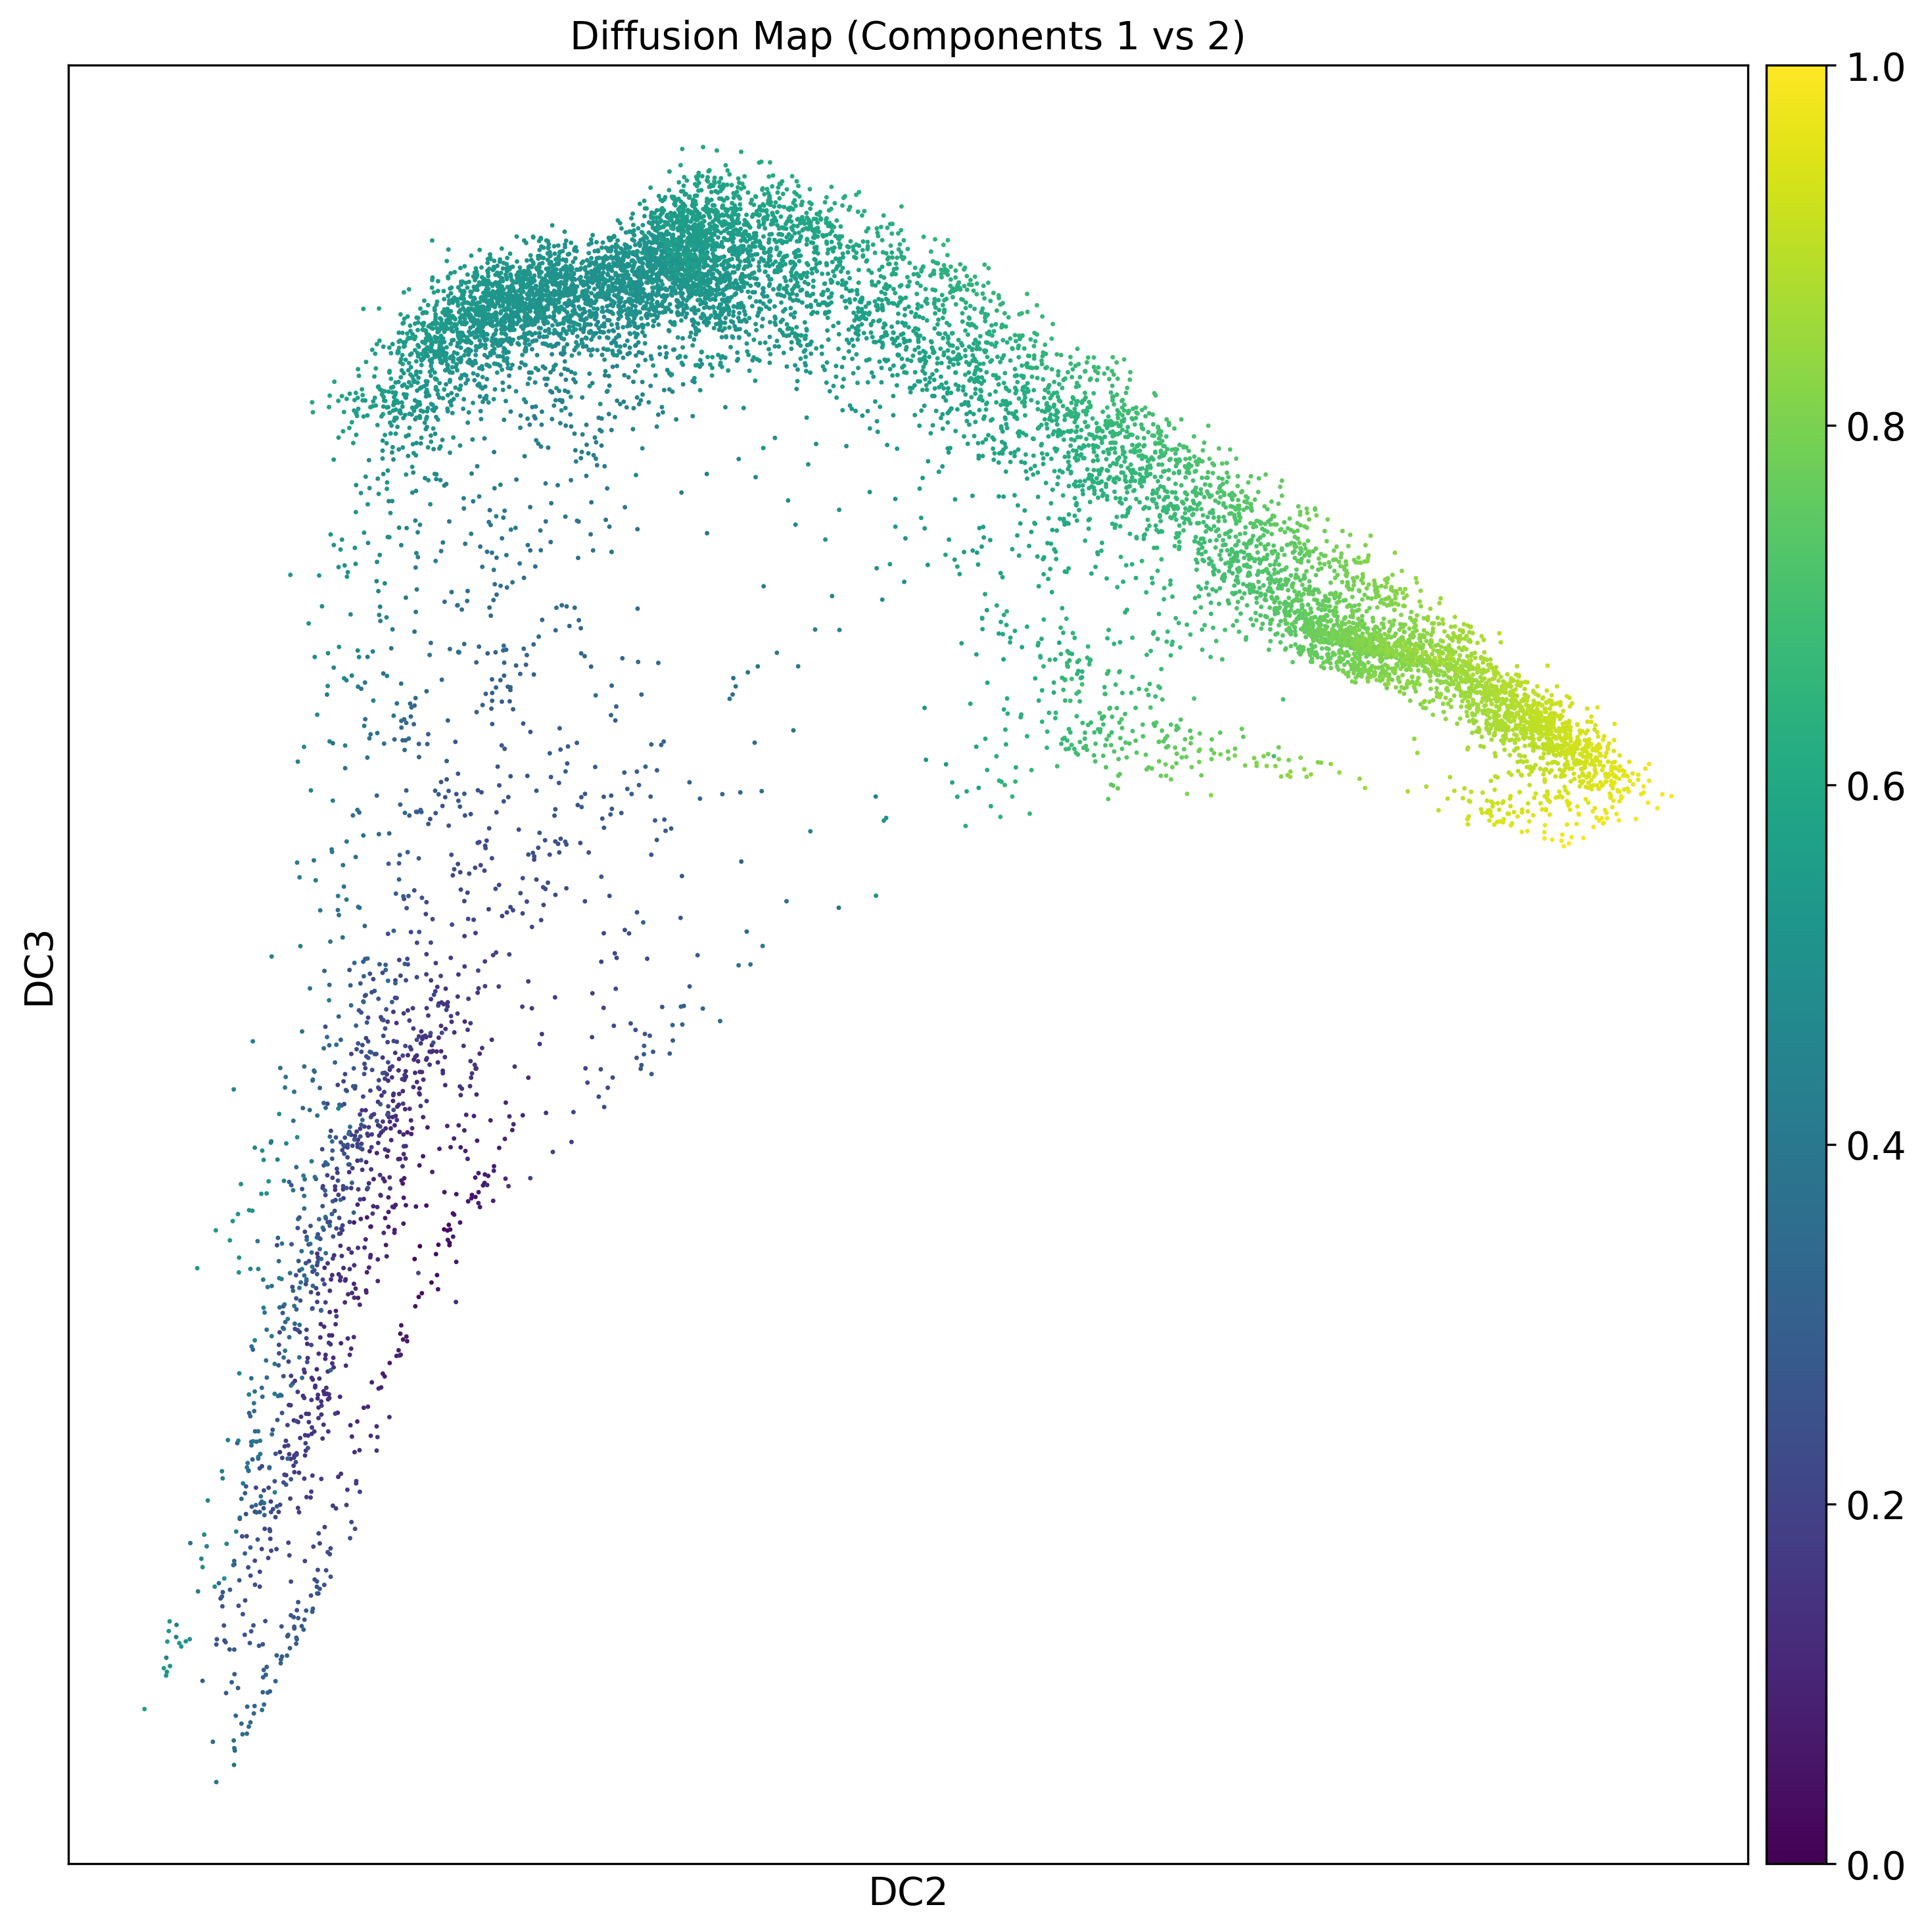

In [137]:
sc.pl.embedding(
    adata_sub, 
    basis='diffmap',  # 使用原始扩散坐标
    components=['2,3'],   # 选择分量1和2
    color=['dpt_pseudotime'],
    title='Diffusion Map (Components 1 vs 2)'
)

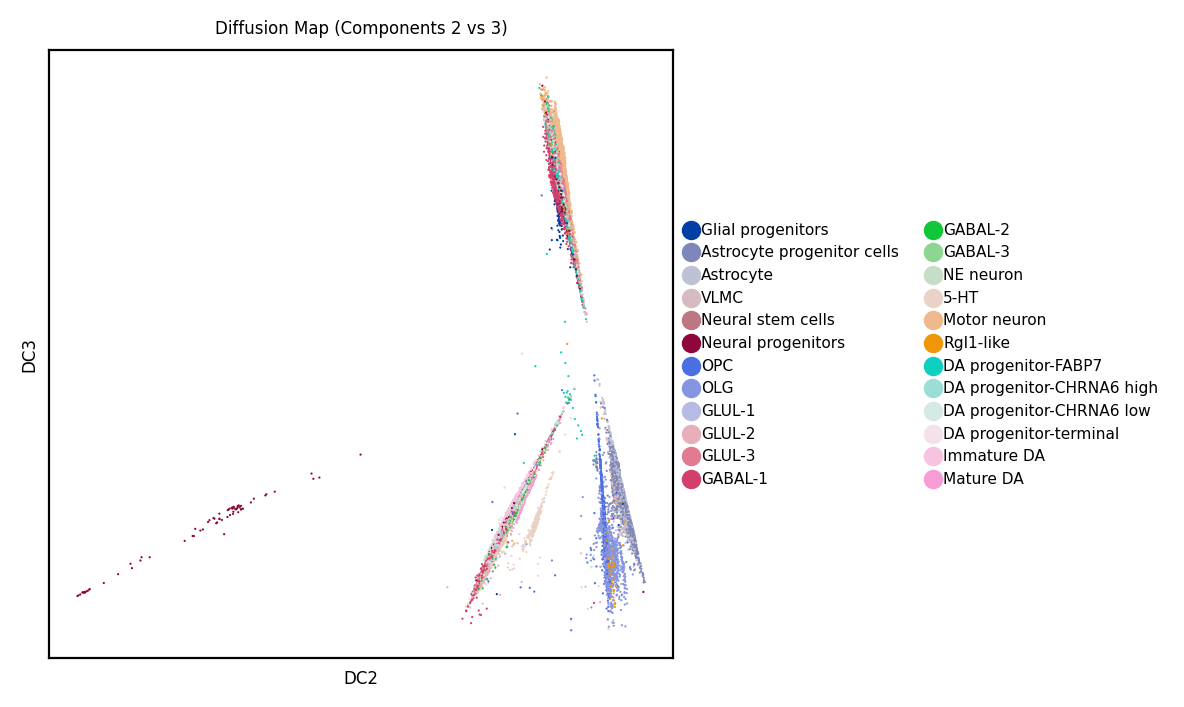

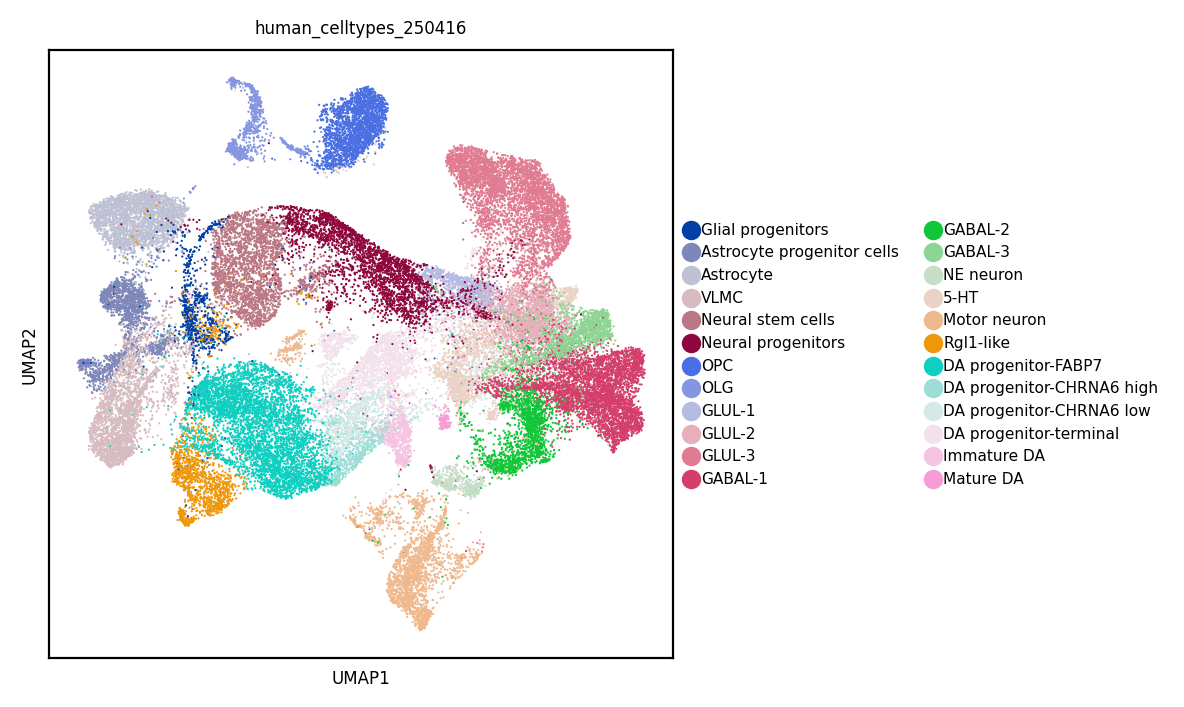

In [18]:

# 方式2：绘制分量2 vs 分量3（常用于观察轨迹分支）
sc.pl.embedding(
    adata, 
    basis='diffmap',  # 使用原始扩散坐标
    color=['human_celltypes_250416'], 
    components=['2,3'],   # 选择分量2和3
    title='Diffusion Map (Components 2 vs 3)'
)

# 方式3：动态交互探索（可选，需要安装plotly）
sc.pl.umap(adata, color='human_celltypes_250416')  # 对比其他降维结果

In [22]:
# 定义多个根节点列表
roots = [
    {'name': 'Neural stem cells', 'human_celltypes_250416': 'Neural stem cells', 'dim':1, 'mode':'min'},
    {'name': 'Rgl1-like', 'human_celltypes_250416': 'Rgl1-like', 'dim':2, 'mode':'max'}
]

for r in roots:
    # 动态生成根细胞
    mask = np.isin(adata.obs['human_celltypes_250416'], [r['human_celltypes_250416']])
    target_dim = adata.obsm['X_diffmap'][mask, r['dim']]
    root_id = np.arange(len(mask))[mask][np.argmin(target_dim) if r['mode']=='min' else np.argmax(target_dim)]
    # 计算并存储伪时间
    adata.uns['iroot'] = root_id
    sc.tl.dpt(adata)
    # 重命名结果字段
    adata.obs[f"dpt_{r['name']}"] = adata.obs['dpt_pseudotime'].copy()
    # 清理默认字段（防止后续覆盖）
    del adata.obs['dpt_pseudotime']

computing Diffusion Pseudotime using n_dcs=10
    finished (0:00:00)
computing Diffusion Pseudotime using n_dcs=10
    finished (0:00:00)


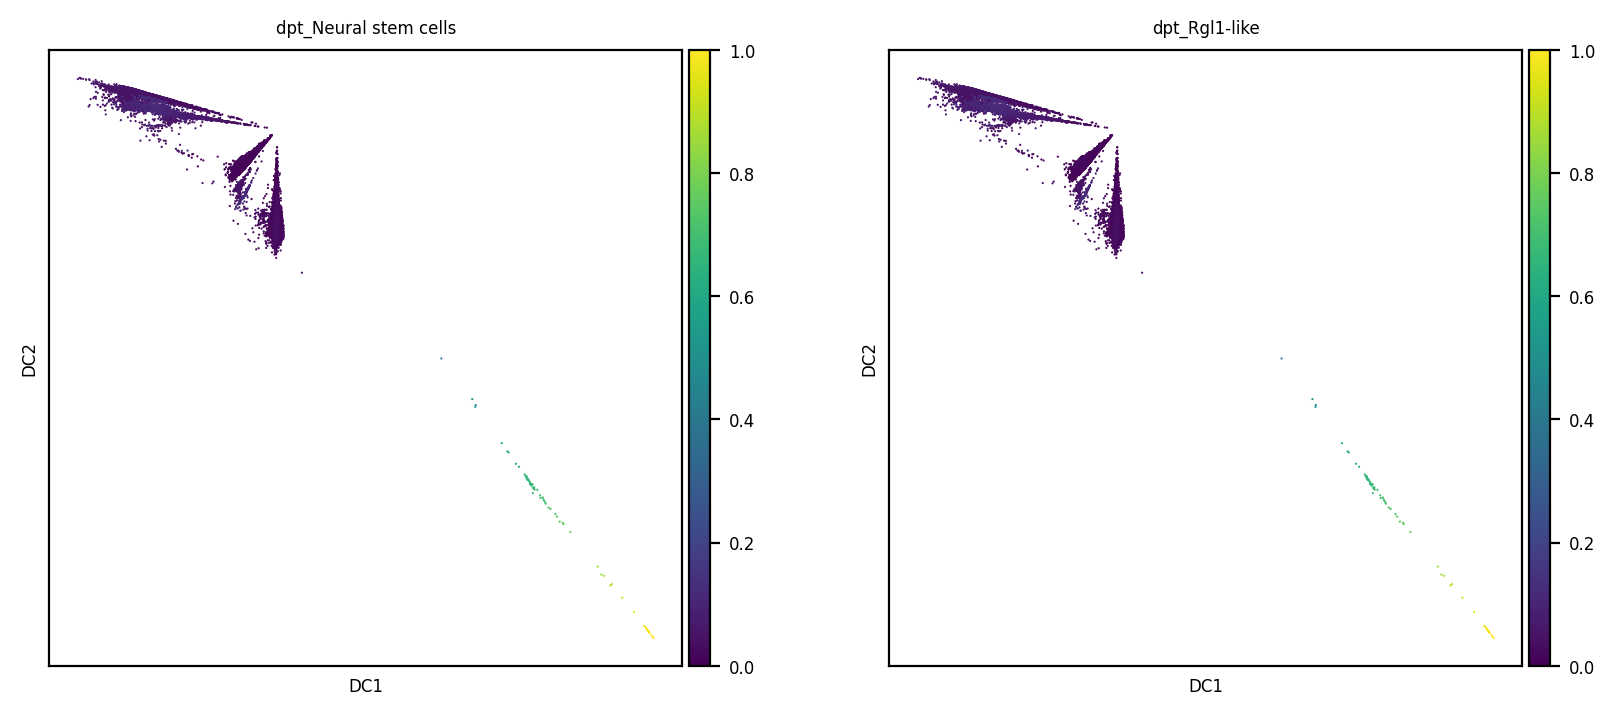

In [24]:
# 绘制不同根节点的伪时间分布
sc.pl.embedding(
    adata,
    basis='diffmap',
    color=["dpt_Neural stem cells", "dpt_Rgl1-like"],  # 替换为你的字段名
    cmap='viridis',
    ncols=2
)

In [26]:
adata.obsm

AxisArrays with keys: X_integrated.rpca, X_pca, X_umap, X_diffmap, X_diffmap_raw

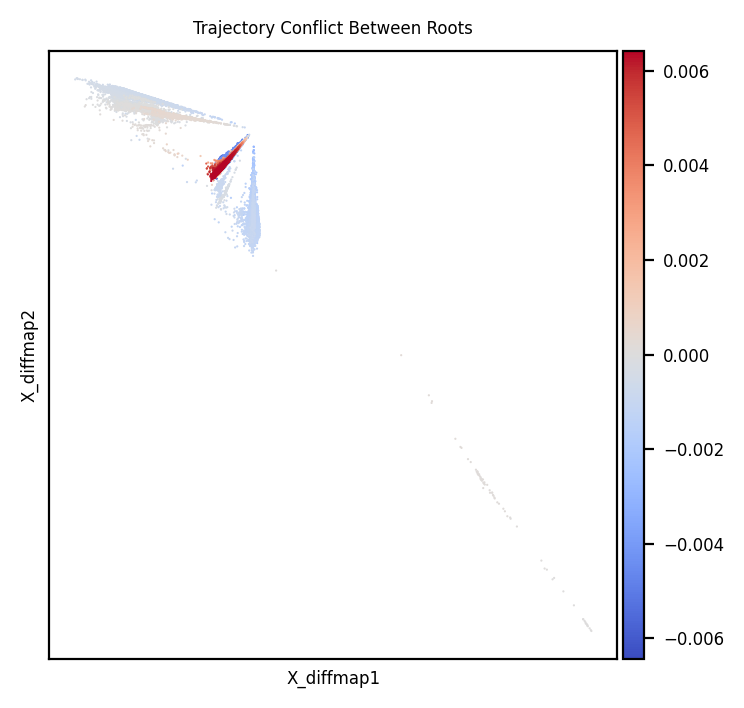

In [27]:
# 计算两个伪时间的差异
adata.obs['dpt_conflict'] = adata.obs['dpt_Neural stem cells'] - adata.obs['dpt_Rgl1-like']

# 绘制冲突热图
sc.pl.embedding(
    adata, 
    basis='X_diffmap', 
    color='dpt_conflict',
    cmap='coolwarm',
    title='Trajectory Conflict Between Roots'
)


In [ ]:
# 选择根
Tn_mask = np.isin(adata.obs['human_celltypes_250416'], ['T'])
min_stem_id = np.argmin(adata.obsm['X_diffmap'][Tn_mask, 1])
root_id = np.arange(len(Tn_mask))[Tn_mask][min_stem_id]
adata.uns['iroot'] = root_id
sc.tl.dpt(adata)

# 重要一步：不然Diffmap的图就不是典型的弧线
adata.obsm['X_diffmap_'] = adata.obsm['X_diffmap'][:,1:]

# 可以出图了
sc.pl.embedding(adata,'diffmap_',color=['dpt_pseudotime','cell_type'])